In [2]:
from scoresbibm.src.utils.data_utils import query, get_summary_df, load_model
from scoresbibm.src.utils.plot import plot_metric_by_num_simulations, use_style,multi_plot

import matplotlib.pyplot as plt

In [3]:
DEFAULT_COLORS = {"npe": "#154c79", "nle": "#1e81b0", "nre": "#76b5c5", "nspe": "#fdae61", "score_transformer": "#d73027", "score_transformer_posterior": "#8b27d7", "score_transformer_directed": "#f25d1d","score_transformer_min_graphical": "#f25d1d", "score_transformer_undirected": "#911c1c", "score_transformer_graphical": "#911c1c"}
figsize_per_row = 1.55
figsize_per_col = 1.85

/mnt/qb/work/macke/mgloeckler90/probjax/scoresbibm/src/utils/data_utils.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_q["value"] = df_q["value"].apply(lambda x: np.array(eval(x)))
/mnt/qb/work/macke/mgloeckler90/probjax/scoresbibm/src/utils/data_utils.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_q["value"] = df_q["value"].apply(lambda x: np.mean(x))
/mnt/qb/work/macke/mgloeckler90/probjax/scoresbibm/src/utils/plot.py:390: UserWarning: The figure layout has changed to tight
  fig.tight_l

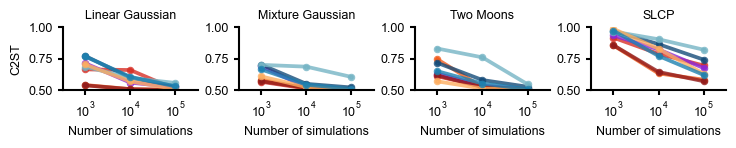

In [3]:
with use_style("pyloric"):
    fig, axes = multi_plot("../../results/main_benchmark", "task", "metric", plot_metric_by_num_simulations, hue="method", color_map=DEFAULT_COLORS, figsize_per_row=figsize_per_row, figsize_per_col=figsize_per_col, legend_ncol=4, method_sde_name="vesde")
    legend = fig.legends[-1]
    fig.legends = []
    fig.savefig("sbibm_task.svg")
    plt.show()

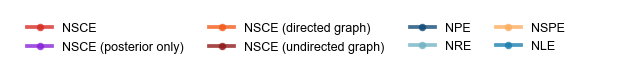

In [4]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(7,0.2))
    ax = plt.gca()
    plt.axis("off")
    legend.set_bbox_to_anchor((0.40, 0.1))
    fig.legends = [legend]
    fig.savefig("method_legend.svg", transparent=True, bbox_inches="tight")
    plt.show()

{'hue': 'method', 'metric': 'c2st', 'method_sde_name': 'vesde', 'task': 'tree_all_cond'}
{'hue': 'method', 'metric': 'c2st', 'method_sde_name': 'vesde', 'task': 'marcov_chain_all_cond'}
{'hue': 'method', 'metric': 'c2st', 'method_sde_name': 'vesde', 'task': 'two_moons_all_cond'}
{'hue': 'method', 'metric': 'c2st', 'method_sde_name': 'vesde', 'task': 'slcp_all_cond'}


/mnt/qb/work/macke/mgloeckler90/probjax/scoresbibm/src/utils/plot.py:390: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


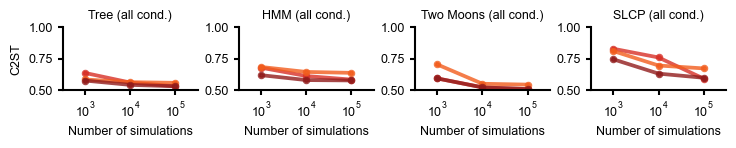

In [5]:
with use_style("pyloric"):
    fig, axes = multi_plot("../../results/main_benchmark_all_cond", "task", "metric", plot_metric_by_num_simulations, hue="method", color_map=DEFAULT_COLORS, figsize_per_row=figsize_per_row, figsize_per_col=figsize_per_col, metric="c2st", method_sde_name="vesde", verbose=True)
    fig.legends = []
    fig.savefig("all_cond_task.svg")
    plt.show()

In [8]:
query("../../results/main_benchmark_all_cond", task="two_moons_all_cond", method_sde_name="vesde", metric="c2st")

,method,task,num_simulations,seed,model_id,metric,value,time_train,time_eval,cfg
0,score_transformer,two_moons_all_cond,1000,0,0,c2st,0.594302,138.849706,4.094095,"{'name': 'main_benchmark_all_cond', 'seed': 0,..."
3,score_transformer,two_moons_all_cond,10000,0,1,c2st,0.523568,339.860200,4.365698,"{'name': 'main_benchmark_all_cond', 'seed': 0,..."
9,score_transformer,two_moons_all_cond,100000,0,3,c2st,0.509790,944.002591,4.347319,"{'name': 'main_benchmark_all_cond', 'seed': 0,..."
54,score_transformer_directed,two_moons_all_cond,1000,0,18,c2st,0.705123,115.762607,4.306099,"{'name': 'main_benchmark_all_cond', 'seed': 0,..."
63,score_transformer_directed,two_moons_all_cond,10000,0,21,c2st,0.551910,358.348922,4.262776,"{'name': 'main_benchmark_all_cond', 'seed': 0,..."
75,score_transformer_directed,two_moons_all_cond,100000,0,25,c2st,0.545312,1021.179483,4.169470,"{'name': 'main_benchmark_all_cond', 'seed': 0,..."
123,score_transformer_undirected,two_moons_all_cond,1000,0,41,c2st,0.594235,120.536765,4.003452,"{'name': 'main_benchmark_all_cond', 'seed': 0,..."
132,score_transformer_undirected,two_moons_all_cond,10000,0,44,c2st,0.523030,337.963611,4.277605,"{'name': 'main_benchmark_all_cond', 'seed': 0,..."
144,score_transformer_undirected,two_moons_all_cond,100000,0,48,c2st,0.509960,951.017837,4.043056,"{'name': 'main_benchmark_all_cond', 'seed': 0,..."


In [26]:
# Make some nice conditonal pictures!!!

model = load_model("../../results/main_benchmark_all_cond",3)

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

from scoresbibm.src.tasks.all_conditional_tasks import TwoMoonsAllConditionalTask
import jax
task = TwoMoonsAllConditionalTask()
reference_sampler = task.get_reference_sampler()

In [63]:
observation_stream = task.get_observation_generator()(jax.random.PRNGKey(0))
_, _, xs = next(observation_stream)

In [81]:
# Posterior
condition_mask_posterior = jax.numpy.array([False, False, True, True])
observation_posterior = xs[condition_mask_posterior]
condition_mask_partial_posterior = jax.numpy.array([False, False, True, False])
observation_partial_posterior = xs[condition_mask_partial_posterior]
condition_mask_partial_posterior2 = jax.numpy.array([False, False, False, True])
observation_partial_posterior2 = xs[condition_mask_partial_posterior]
condition_mask_partial_emulation = jax.numpy.array([True, False, False, True])
observation_partial_emulation = xs[condition_mask_partial_emulation]


In [100]:
samples1 = model.sample(1000, condition_mask=condition_mask_posterior, x_o=observation_posterior, rng=jax.random.PRNGKey(0))
samples_reference1 = reference_sampler.sample(1000, condition_mask=condition_mask_posterior, x_o=observation_posterior, rng=jax.random.PRNGKey(0))

In [101]:
samples2 = model.sample(1000, condition_mask=condition_mask_partial_posterior, x_o=observation_partial_posterior, rng=jax.random.PRNGKey(0))[:,:2]
samples_reference2 = reference_sampler.sample(1000, condition_mask=condition_mask_partial_posterior, x_o=observation_partial_posterior, rng=jax.random.PRNGKey(0))[:,:2]

In [102]:
samples3 = model.sample(1000, condition_mask=condition_mask_partial_posterior2, x_o=observation_partial_posterior2, rng=jax.random.PRNGKey(0))[:,:2]
samples_reference3 = reference_sampler.sample(1000, condition_mask=condition_mask_partial_posterior2, x_o=observation_partial_posterior2, rng=jax.random.PRNGKey(0))[:,:2]

In [103]:
samples4 = model.sample(1000, condition_mask=condition_mask_partial_emulation, x_o=observation_partial_emulation, rng=jax.random.PRNGKey(0))[:,:2]
samples_reference4 = reference_sampler.sample(1000, condition_mask=condition_mask_partial_emulation, x_o=observation_partial_emulation, rng=jax.random.PRNGKey(0))[:,:2]

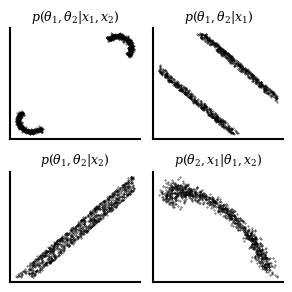

In [110]:
with use_style("pyloric"):
    fig, axes = plt.subplots(2, 2, figsize=(3, 3))
    axes[0,0].scatter(samples1[:,0], samples1[:,1], s=0.1, color="black")
    axes[0,0].set_title(r"$p(\theta_1, \theta_2|x_1, x_2)$")
    #axes[0,0].scatter(samples_reference1[:,0], samples_reference1[:,1], s=0.01, alpha=0.1, color="black")
    axes[0,0].axes.get_xaxis().set_visible(False)
    axes[0,0].axes.get_yaxis().set_visible(False)
    
    axes[0,1].scatter(samples2[:,0], samples2[:,1],  s=0.1, color="black")
    axes[0,1].set_title(r"$p(\theta_1, \theta_2|x_1)$")
    #axes[0,1].scatter(samples_reference2[:,0], samples_reference2[:,1], s=0.01, alpha=0.1, color="black")
    axes[0,1].axes.get_xaxis().set_visible(False)
    axes[0,1].axes.get_yaxis().set_visible(False)
    
    axes[1,0].scatter(samples3[:,0], samples3[:,1], s=0.1, color="black")
    axes[1,0].set_title(r"$p(\theta_1, \theta_2|x_2)$")
    #axes[1,0].scatter(samples_reference3[:,0], samples_reference3[:,1], s=0.01, alpha=0.1, color="black")
    axes[1,0].axes.get_xaxis().set_visible(False)
    axes[1,0].axes.get_yaxis().set_visible(False)
    
    axes[1,1].scatter(samples4[:,0], samples4[:,1],  s=0.1, color="black")
    axes[1,1].set_title(r"$p(\theta_2,x_1|\theta_1,x_2)$")
    #axes[1,1].scatter(samples_reference4[:,0], samples_reference4[:,1], s=0.01, alpha=0.1, color="black")
    axes[1,1].axes.get_xaxis().set_visible(False)
    axes[1,1].axes.get_yaxis().set_visible(False)
    

    fig.tight_layout()
    fig.savefig("conditional_two_moons.svg")
